In [19]:
from datascience import *
import numpy as np

from matplotlib import pyplot as plt

plt.style.use('fivethirtyeight')

%matplotlib inline

In [20]:
births = Table.read_table('baby.csv')
births.show(5)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False


In [21]:
def one_boot_strap_mean():
    resample = births.sample()
    return np.mean(resample.column('Maternal Age'))

In [22]:
num_reps = 3000
btstrap_means = make_array()
for i in np.arange(num_reps):
    btstrap_means = np.append(btstrap_means, one_boot_strap_mean())

In [23]:
left = np.percentile(btstrap_means, 2.5)
right = np.percentile(btstrap_means, 97.5)

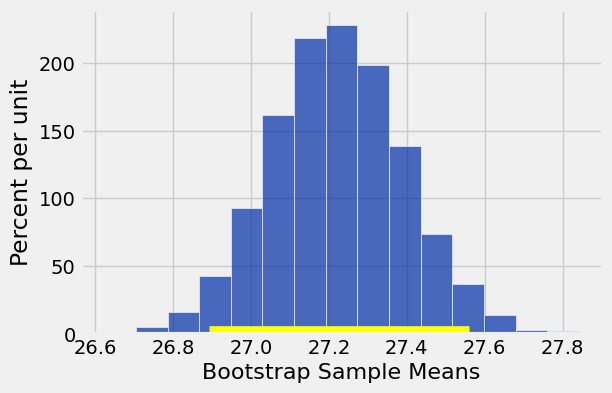

In [24]:
resampled_means = Table().with_column('Bootstrap Sample Means', btstrap_means)

resampled_means.hist(bins=15)
plt.plot([left, right], [0, 0], color='yellow', lw=12)

In [25]:
left, right

(26.893483816013632, 27.559625212947189)

In [26]:
sampled_ages = births.column("Maternal Age")
sample_size = len(sampled_ages)
sample_average = np.average(sampled_ages)
sample_sd = np.std(sampled_ages)
sample_size, sample_average, sample_sd

(1174, 27.228279386712096, 5.8153604041908968)

In [27]:
estimated_sd_of_sample_average = sample_sd / np.sqrt(sample_size)
estimated_sd_of_sample_average

0.16972373742299796

In [28]:
sample_average - 2 * estimated_sd_of_sample_average, sample_average + 2 * estimated_sd_of_sample_average

(26.888831911866099, 27.567726861558093)

In [34]:
number_of_ones = 6
zero_one_population = np.append(np.ones(number_of_ones), np.zeros(10 - number_of_ones))
print("Standard Deviation", np.round(np.std(zero_one_population), 2))

zero_one_population

Standard Deviation 0.49


array([ 1.,  1.,  1.,  1.,  1.,  1.,  0.,  0.,  0.,  0.])

In [35]:
def sd_of_zero_ones(number_of_ones):
    zero_one_population = zero_one_population = np.append(np.ones(number_of_ones), np.zeros(10 - number_of_ones))
    return np.std(zero_one_population)

In [36]:
possible_ones = np.arange(11)
zero_one_pop = Table().with_columns(
    "Number of Ones", possible_ones,
    "Proportion of Ones", possible_ones / 10
)
zero_one_pop

Number of Ones,Proportion of Ones
0,0
1,0.1
2,0.2
3,0.3
4,0.4
5,0.5
6,0.6
7,0.7
8,0.8
9,0.9


In [37]:
sds = zero_one_pop.apply(sd_of_zero_ones, "Number of Ones")
zero_one_pop = zero_one_pop.with_column("Pop SD", sds)
zero_one_pop.show()

Number of Ones,Proportion of Ones,Pop SD
0,0,0
1,0.1,0.3
2,0.2,0.4
3,0.3,0.458258
4,0.4,0.489898
5,0.5,0.5
6,0.6,0.489898
7,0.7,0.458258
8,0.8,0.4
9,0.9,0.3


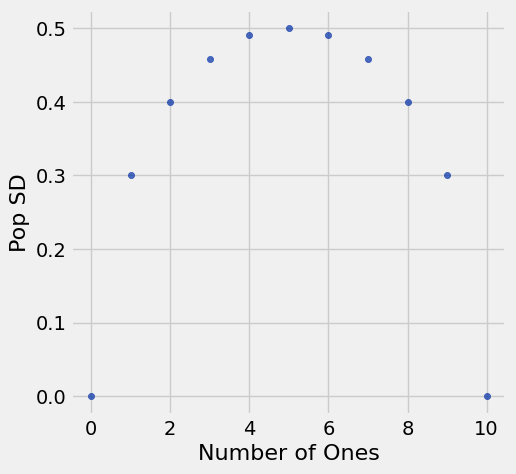

In [40]:
zero_one_pop.scatter("Number of Ones", "Pop SD")

In [42]:
x = (4 * 0.5) / 100
x

0.02